<a href="https://colab.research.google.com/github/MhThorq/AnomaliEwallet/blob/main/AnomaliEwallet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import imblearn

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Paysim/PS_20174392719_1491204439457_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


**Pre-processing & Feature Engineering**

In [4]:
# Menghapus kolom yang tidak diperlukan
df_clean = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

# Mengubah kolom 'type' menjadi kolom numerik dengan One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=['type'])

# Membuat fitur selisih saldo (Error Balance)
df_encoded['errorBalanceOrig'] = df_encoded['newbalanceOrig'] + df_encoded['amount'] - df_encoded['oldbalanceOrg']
df_encoded['errorBalanceDest'] = df_encoded['oldbalanceDest'] + df_encoded['amount'] - df_encoded['newbalanceDest']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Fitur yang akan discale (kecuali target isFraud)
features = df_encoded.drop('isFraud', axis=1)
X_scaled = scaler.fit_transform(features)
y = df_encoded['isFraud']

**Implementasi Pendekatan Hybrid (Tahap Unsupervised)**

In [5]:
from sklearn.ensemble import IsolationForest

# 1. Inisialisasi Model
# contamination: estimasi persentase anomali (bisa disesuaikan berdasarkan EDA)
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# 2. Fit Model (Hanya menggunakan fitur X, tanpa label 'isFraud')
# Gunakan data yang sudah di-scale dari tahap 2
iso_forest.fit(X_scaled)

# 3. Mendapatkan Prediksi dan Skor Anomali
# predict(): menghasilkan 1 (normal) dan -1 (anomali)
# decision_function(): menghasilkan skor numerik (semakin rendah, semakin anomali)
df_encoded['anomaly_label'] = iso_forest.predict(X_scaled)
df_encoded['anomaly_score'] = iso_forest.decision_function(X_scaled)

**Implementasi Pendekatan Hybrid (Tahap Supervised)**

In [6]:
# Menyiapkan fitur (X) dan target (y)
# X berisi fitur asli yang sudah di-pre-processing + fitur dari Isolation Forest
X = df_encoded.drop('isFraud', axis=1)
y = df_encoded['isFraud']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Pelatihan model
rf_model.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(max_depth=10, random_state=42)

**Evaluasi dan Visualisasi**

In [10]:
from sklearn.metrics import classification_report

# Melakukan prediksi pada data testing
y_pred = rf_model.predict(X_test)

# Menampilkan laporan klasifikasi
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



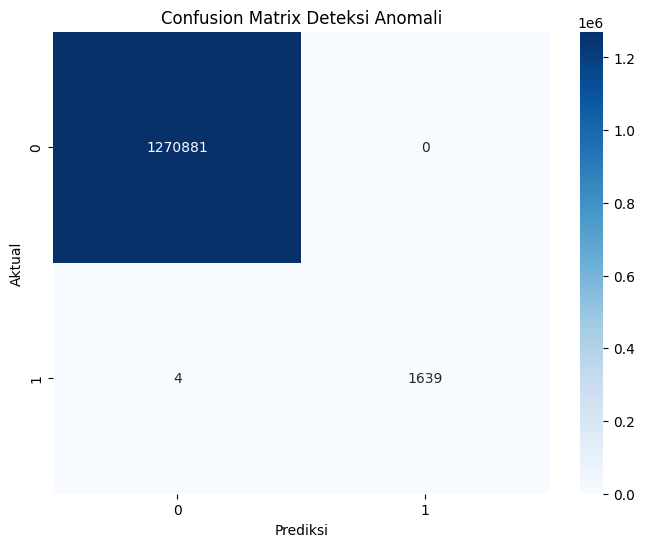

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Deteksi Anomali')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

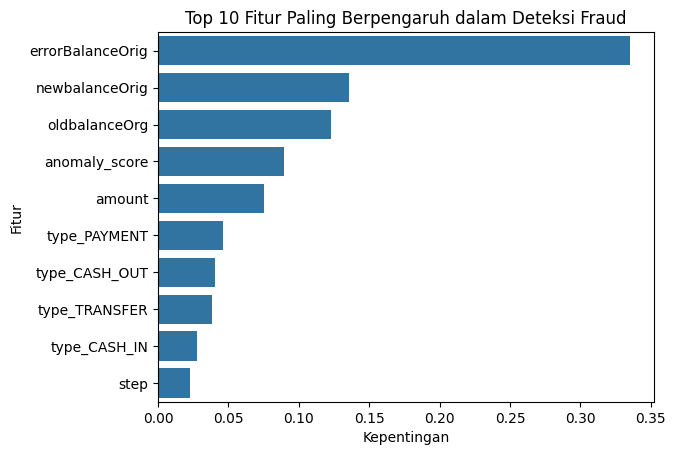

In [12]:
# Mendapatkan nilai pentingnya fitur
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Fitur': feature_names, 'Kepentingan': importances})
feature_importance_df = feature_importance_df.sort_values(by='Kepentingan', ascending=False)

# Visualisasi
sns.barplot(x='Kepentingan', y='Fitur', data=feature_importance_df.head(10))
plt.title('Top 10 Fitur Paling Berpengaruh dalam Deteksi Fraud')
plt.show()